
# Career–City Fit MVP: 2024 BLS OEWS + ACS Data Pipeline

This notebook does five things:

1. downloads the **2024 BLS OEWS metro/nonmetro file** and the **2024 BLS MSA definitions** helper file,
2. downloads **2024 ACS 1-year** metro-level housing/context data,
3. converts the raw inputs to CSV,
4. cleans the data and attempts to merge it into an **occupation × metro** dataset,
5. runs a first round of exploratory data analysis and produces a few charts.

## Scope

This is a **2024-only MVP**. It is designed to get one clean cross-section working end-to-end before backfilling additional years.

## Notes

- The ACS API request in this notebook works without a key for small requests, but you can optionally set `CENSUS_API_KEY`.
- The BLS OEWS metro/nonmetro file is currently linked as a ZIP archive from the BLS OEWS tables page, so this notebook downloads the ZIP, inspects its contents, and extracts the spreadsheet automatically.
- The merge uses the **BLS 2024 MSA definitions workbook** as a helper crosswalk and falls back to **normalized metro-name matching** if a direct code-based join is not available.



## 0. Optional package install

Uncomment and run this cell once if your environment is missing any of these packages.


In [22]:

%pip install -q polars pandas openpyxl requests matplotlib pyarrow scikit-learn


Note: you may need to restart the kernel to use updated packages.


## 1. Imports and notebook configuration

In [3]:

from __future__ import annotations

import io
import json
import math
import os
import re
import zipfile
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import requests
from IPython.display import display

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(80)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
FIG_DIR = PROJECT_ROOT / "figures"

for path in [RAW_DIR / "bls", RAW_DIR / "acs", INTERIM_DIR, PROCESSED_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

USER_AGENT = "career-city-fit-notebook/1.0 (education project)"
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": USER_AGENT})


In [23]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler

## 2. Configuration

In [4]:

BLS_OEWS_ZIP_URL = "https://www.bls.gov/oes/special-requests/oesm24ma.zip"
BLS_MSA_DEFINITIONS_URL = "https://www.bls.gov/oes/area_definitions_m2024.xlsx"
ACS_BASE_URL = "https://api.census.gov/data/2024/acs/acs1"

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

BLS_ZIP_PATH = RAW_DIR / "bls" / "oesm24ma.zip"
BLS_EXTRACT_DIR = RAW_DIR / "bls" / "oesm24ma_extracted"
BLS_MSA_DEFINITIONS_PATH = RAW_DIR / "bls" / "area_definitions_m2024.xlsx"

ACS_RAW_JSON_PATH = RAW_DIR / "acs" / "acs_2024_metro_raw.json"
ACS_RAW_CSV_PATH = RAW_DIR / "acs" / "acs_2024_metro_raw.csv"

BLS_RAW_CSV_PATH = RAW_DIR / "bls" / "oews_2024_raw.csv"
BLS_CROSSWALK_CSV_PATH = INTERIM_DIR / "bls_metro_crosswalk_2024.csv"
ACS_CLEAN_CSV_PATH = INTERIM_DIR / "acs_2024_metro_context.csv"
BLS_CLEAN_CSV_PATH = INTERIM_DIR / "oews_2024_occ_metro.csv"
MERGED_CSV_PATH = PROCESSED_DIR / "occ_metro_2024_merged.csv"
UNMATCHED_BLS_METROS_CSV_PATH = INTERIM_DIR / "bls_unmatched_metros.csv"


## 3. Helper functions

In [5]:

def download_file(url: str, destination: Path, overwrite: bool = False, chunk_size: int = 1024 * 1024) -> Path:
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and not overwrite:
        print(f"Using existing file: {destination}")
        return destination

    print(f"Downloading: {url}")
    with SESSION.get(url, stream=True, timeout=120) as response:
        response.raise_for_status()
        with open(destination, "wb") as f:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)

    print(f"Saved: {destination} ({destination.stat().st_size / 1_000_000:.2f} MB)")
    return destination


def sanitize_column_name(name: str) -> str:
    name = str(name).strip().lower()
    name = re.sub(r"[%/]", " ", name)
    name = re.sub(r"[^a-z0-9]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def sanitize_columns(columns: Iterable[str]) -> list[str]:
    return [sanitize_column_name(c) for c in columns]


def normalize_metro_name(value: str | None) -> str | None:
    if value is None:
        return None
    text = str(value).strip().lower()

    replacements = {
        "&": " and ",
        "/": " ",
        ".": "",
        ", usa": "",
        " metro area": "",
        " micro area": "",
        " metropolitan statistical area": "",
        " micropolitan statistical area": "",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    # Remove generic words that often differ across sources.
    text = re.sub(r"\b(area|division|the)\b", " ", text)

    # Normalize whitespace / punctuation.
    text = re.sub(r"[^a-z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


def pick_first_existing(columns: list[str], candidates: list[str]) -> str | None:
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def to_numeric_expr(column_name: str, dtype: pl.DataType = pl.Float64) -> pl.Expr:
    return (
        pl.col(column_name)
        .cast(pl.Utf8)
        .str.replace_all(",", "")
        .str.replace_all(r"[^0-9.\-]", "")
        .replace("", None)
        .cast(dtype, strict=False)
        .alias(column_name)
    )


def display_pl(df: pl.DataFrame, rows: int = 8):
    display(df.head(rows).to_pandas())


def print_shape(label: str, df: pl.DataFrame):
    print(f"{label}: {df.height:,} rows × {df.width:,} cols")


def acs_params() -> dict:
    params = {
        "get": "NAME,B25064_001E,B19013_001E,B01003_001E",
        "for": "metropolitan statistical area/micropolitan statistical area:*",
    }
    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY
    return params


## 4. Download raw source files

In [6]:

# 4a. Download the BLS OEWS ZIP and the BLS 2024 MSA definitions workbook.
download_file(BLS_OEWS_ZIP_URL, BLS_ZIP_PATH)
download_file(BLS_MSA_DEFINITIONS_URL, BLS_MSA_DEFINITIONS_PATH)

# 4b. Download ACS 2024 1-year metro/micro data from the Census API.
print("Requesting ACS 2024 API data...")
acs_response = SESSION.get(ACS_BASE_URL, params=acs_params(), timeout=120)
acs_response.raise_for_status()

acs_json = acs_response.json()
with open(ACS_RAW_JSON_PATH, "w", encoding="utf-8") as f:
    json.dump(acs_json, f)

acs_header = acs_json[0]
acs_rows = acs_json[1:]
acs_raw_pd = pd.DataFrame(acs_rows, columns=acs_header)
acs_raw_pd.to_csv(ACS_RAW_CSV_PATH, index=False)

print(f"Saved ACS raw JSON: {ACS_RAW_JSON_PATH}")
print(f"Saved ACS raw CSV:  {ACS_RAW_CSV_PATH}")
display(acs_raw_pd.head())


Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm24ma.zip
Using existing file: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/area_definitions_m2024.xlsx
Requesting ACS 2024 API data...
Saved ACS raw JSON: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2024_metro_raw.json
Saved ACS raw CSV:  /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/acs/acs_2024_metro_raw.csv


,NAME,B25064_001E,B19013_001E,B01003_001E,metropolitan statistical area/micropolitan statistical area
0,"Aberdeen, WA Micro Area",1127,59619,77893,10140
1,"Abilene, TX Metro Area",1173,63390,181969,10180
2,"Adrian, MI Micro Area",962,71632,97746,10300
3,"Aguadilla, PR Metro Area",572,24351,250969,10380
4,"Akron, OH Metro Area",1059,71364,702209,10420


## 5. Inspect and extract the BLS OEWS ZIP

In [7]:

BLS_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(BLS_ZIP_PATH, "r") as zf:
    names = zf.namelist()
    print("ZIP contents:")
    for name in names:
        print(" -", name)

    candidate_files = [
        name for name in names
        if name.lower().endswith((".xlsx", ".xls", ".csv", ".txt"))
    ]
    if not candidate_files:
        raise FileNotFoundError("No spreadsheet or text file was found inside the BLS ZIP.")

    # Prefer Excel if available, then CSV, then TXT.
    preferred_order = [".xlsx", ".xls", ".csv", ".txt"]
    extracted_member = None
    for ext in preferred_order:
        matches = [name for name in candidate_files if name.lower().endswith(ext)]
        if matches:
            extracted_member = matches[2]
            break

    assert extracted_member is not None
    print(f"Chosen BLS data file inside ZIP: {extracted_member}")
    zf.extract(extracted_member, path=BLS_EXTRACT_DIR)

BLS_EXTRACTED_PATH = BLS_EXTRACT_DIR / extracted_member
print("Extracted path:", BLS_EXTRACTED_PATH)


ZIP contents:
 - oesm24ma/
 - oesm24ma/BOS_M2024_dl.xlsx
 - oesm24ma/file_descriptions.xlsx
 - oesm24ma/MSA_M2024_dl.xlsx
Chosen BLS data file inside ZIP: oesm24ma/MSA_M2024_dl.xlsx
Extracted path: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oesm24ma_extracted/oesm24ma/MSA_M2024_dl.xlsx


## 6. Read the raw BLS file and convert it to CSV

In [8]:

suffix = BLS_EXTRACTED_PATH.suffix.lower()

if suffix in {".xlsx", ".xls"}:
    # Read only the first sheet. If the workbook has multiple sheets,
    # inspect them manually and switch the sheet_name if needed.
    bls_raw_pd = pd.read_excel(BLS_EXTRACTED_PATH, sheet_name=0)
elif suffix == ".csv":
    bls_raw_pd = pd.read_csv(BLS_EXTRACTED_PATH)
elif suffix == ".txt":
    # Fall back to pandas' default delimiter detection.
    bls_raw_pd = pd.read_csv(BLS_EXTRACTED_PATH, sep=None, engine="python")
else:
    raise ValueError(f"Unsupported extracted BLS file type: {suffix}")

bls_raw_pd.to_csv(BLS_RAW_CSV_PATH, index=False)

print("Raw BLS columns:")
print(list(bls_raw_pd.columns))
print(f"Raw BLS shape: {bls_raw_pd.shape[0]:,} rows × {bls_raw_pd.shape[1]:,} cols")
display(bls_raw_pd.head())
print(f"Saved raw BLS CSV: {BLS_RAW_CSV_PATH}")


Raw BLS columns:
['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE', 'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP', 'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT', 'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN', 'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75', 'A_PCT90', 'ANNUAL', 'HOURLY']
Raw BLS shape: 150,176 rows × 32 cols


,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,20.25,29.34,45.3,23120,29640,42120,61020,94220,NaN,NaN
1,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,42.03,61.17,84.3,44710,61250,87420,127230,175350,NaN,NaN
2,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,85.35,#,#,99140,107040,177520,#,#,NaN,NaN
3,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-1021,General and Operations Managers,...,37.18,58.64,87.22,35980,50640,77340,121970,181420,NaN,NaN
4,10180,"Abilene, TX",4,TX,0,Cross-industry,cross-industry,1235,11-2021,Marketing Managers,...,50.02,73.86,99.9,58480,82560,104030,153630,207790,NaN,NaN


Saved raw BLS CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/raw/bls/oews_2024_raw.csv


## 7. Build a BLS metro crosswalk from the 2024 MSA definitions workbook

In [9]:

msa_defs_pd = pd.read_excel(BLS_MSA_DEFINITIONS_PATH)
msa_defs_pd.columns = [str(c).strip() for c in msa_defs_pd.columns]
display(msa_defs_pd.head())

msa_defs = pl.from_pandas(msa_defs_pd)
msa_defs.columns = sanitize_columns(msa_defs.columns)

# The original sheet uses a header with a trailing space: "May 2024 MSA code ".
# After sanitizing, it becomes "may_2024_msa_code".
crosswalk = (
    msa_defs
    .rename({
        "may_2024_msa_code": "cbsa_code",
        "may_2024_msa_name": "bls_msa_name",
        "state_abbreviation": "state_abbr",
        "county_name": "county_name",
    })
    .select(["cbsa_code", "bls_msa_name"])
    .drop_nulls()
    .unique()
    .with_columns([
        pl.col("cbsa_code").cast(pl.Int64, strict=False),
        pl.col("bls_msa_name").cast(pl.Utf8),
    ])
    # Keep metro codes only. BLS nonmetro helper codes are 6 digits or larger,
    # while standard CBSA metro codes are 5 digits.
    .filter(pl.col("cbsa_code") < 100000)
    .filter(~pl.col("bls_msa_name").str.to_lowercase().str.contains("nonmetropolitan"))
    .with_columns([
        pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code"),
        pl.col("bls_msa_name").map_elements(normalize_metro_name, return_dtype=pl.Utf8).alias("metro_name_norm"),
    ])
    .sort("cbsa_code")
)

crosswalk.write_csv(BLS_CROSSWALK_CSV_PATH)

print_shape("BLS metro crosswalk", crosswalk)
display_pl(crosswalk)
print(f"Saved: {BLS_CROSSWALK_CSV_PATH}")


,FIPS code,State,State abbreviation,May 2024 MSA code,May 2024 MSA name,County code,County name
0,1,Alabama,AL,33860,"Montgomery, AL",1,Autauga County
1,1,Alabama,AL,19300,"Daphne-Fairhope-Foley, AL",3,Baldwin County
2,1,Alabama,AL,100004,Southeast Alabama nonmetropolitan area,5,Barbour County
3,1,Alabama,AL,13820,"Birmingham, AL",7,Bibb County
4,1,Alabama,AL,13820,"Birmingham, AL",9,Blount County


BLS metro crosswalk: 393 rows × 3 cols


,cbsa_code,bls_msa_name,metro_name_norm
0,10180,"Abilene, TX",abilene tx
1,10380,"Aguadilla, PR",aguadilla pr
2,10420,"Akron, OH",akron oh
3,10500,"Albany, GA",albany ga
4,10540,"Albany, OR",albany or
5,10580,"Albany-Schenectady-Troy, NY",albany schenectady troy ny
6,10740,"Albuquerque, NM",albuquerque nm
7,10780,"Alexandria, LA",alexandria la


Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/bls_metro_crosswalk_2024.csv


## 8. Clean ACS into a metro-level context table

In [10]:

acs_raw = pl.read_csv(ACS_RAW_CSV_PATH)
acs_raw.columns = sanitize_columns(acs_raw.columns)

# Identify the long geography-code column produced by the ACS API.
geo_code_col = pick_first_existing(
    acs_raw.columns,
    [
        "metropolitan_statistical_area_micropolitan_statistical_area",
        "metropolitan_statistical_area",
        "micropolitan_statistical_area",
    ],
)

if geo_code_col is None:
    raise KeyError(
        "Could not identify the ACS geography code column. "
        f"Available columns: {acs_raw.columns}"
    )

acs_clean = (
    acs_raw
    .rename({
        "name": "acs_area_name",
        geo_code_col: "cbsa_code",
        "b25064_001e": "median_gross_rent",
        "b19013_001e": "median_household_income",
        "b01003_001e": "population",
    })
    .with_columns([
        pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code"),
        to_numeric_expr("median_gross_rent", pl.Int64),
        to_numeric_expr("median_household_income", pl.Int64),
        to_numeric_expr("population", pl.Int64),
    ])
    .join(
        crosswalk.select(["cbsa_code", "bls_msa_name", "metro_name_norm"]),
        on="cbsa_code",
        how="inner",
    )
    .with_columns([
        pl.lit(2024).alias("year"),
        (pl.col("median_gross_rent") * 12).alias("annual_rent"),
        pl.col("acs_area_name").map_elements(normalize_metro_name, return_dtype=pl.Utf8).alias("acs_name_norm"),
    ])
    .select([
        "year",
        "cbsa_code",
        "bls_msa_name",
        "acs_area_name",
        "median_gross_rent",
        "annual_rent",
        "median_household_income",
        "population",
        "metro_name_norm",
        "acs_name_norm",
    ])
    .sort("cbsa_code")
)

acs_clean.write_csv(ACS_CLEAN_CSV_PATH)

print_shape("ACS clean metro context", acs_clean)
display_pl(acs_clean)
print(f"Saved: {ACS_CLEAN_CSV_PATH}")


ACS clean metro context: 393 rows × 10 cols


,year,cbsa_code,bls_msa_name,acs_area_name,median_gross_rent,annual_rent,median_household_income,population,metro_name_norm,acs_name_norm
0,2024,10180,"Abilene, TX","Abilene, TX Metro Area",1173,14076,63390,181969,abilene tx,abilene tx
1,2024,10380,"Aguadilla, PR","Aguadilla, PR Metro Area",572,6864,24351,250969,aguadilla pr,aguadilla pr
2,2024,10420,"Akron, OH","Akron, OH Metro Area",1059,12708,71364,702209,akron oh,akron oh
3,2024,10500,"Albany, GA","Albany, GA Metro Area",975,11700,56851,146051,albany ga,albany ga
4,2024,10540,"Albany, OR","Albany, OR Metro Area",1363,16356,80422,132474,albany or,albany or
5,2024,10580,"Albany-Schenectady-Troy, NY","Albany-Schenectady-Troy, NY Metro Area",1341,16092,86637,913485,albany schenectady troy ny,albany schenectady troy ny
6,2024,10740,"Albuquerque, NM","Albuquerque, NM Metro Area",1220,14640,76097,929919,albuquerque nm,albuquerque nm
7,2024,10780,"Alexandria, LA","Alexandria, LA Metro Area",899,10788,55909,148008,alexandria la,alexandria la


Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/acs_2024_metro_context.csv


## 9. Clean raw BLS OEWS data into occupation × metro rows

In [11]:
bls_raw = pl.read_csv(BLS_RAW_CSV_PATH, infer_schema_length=5000, ignore_errors=True)
bls_raw.columns = sanitize_columns(bls_raw.columns)

print("Sanitized raw BLS columns:")
print(bls_raw.columns)

expected_bls_cols = [
    "area",
    "area_title",
    "area_type",
    "prim_state",
    "naics",
    "naics_title",
    "i_group",
    "own_code",
    "occ_code",
    "occ_title",
    "o_group",
    "tot_emp",
    "emp_prse",
    "jobs_1000",
    "loc_quotient",
    "pct_total",
    "pct_rpt",
    "h_mean",
    "a_mean",
    "mean_prse",
    "h_pct10",
    "h_pct25",
    "h_median",
    "h_pct75",
    "h_pct90",
    "a_pct10",
    "a_pct25",
    "a_median",
    "a_pct75",
    "a_pct90",
    "annual",
    "hourly",
]

missing_cols = [c for c in ["area", "area_title", "occ_code", "occ_title", "o_group"] if c not in bls_raw.columns]
if missing_cols:
    raise KeyError(f"Missing required BLS columns: {missing_cols}")

# Optional diagnostics: inspect the slice values before filtering
for col in ["area_type", "i_group", "own_code", "naics", "naics_title", "o_group"]:
    if col in bls_raw.columns:
        print(f"\nUnique sample values for {col}:")
        print(
            bls_raw.select(col)
            .drop_nulls()
            .unique()
            .sort(col)
            .head(20)
            .to_pandas()
        )

bls_clean = (
    bls_raw
    .select([c for c in expected_bls_cols if c in bls_raw.columns])
    .with_columns([
        pl.lit(2024).alias("year"),
        pl.col("area").cast(pl.Utf8).str.strip_chars().alias("area"),
        pl.col("area_title").cast(pl.Utf8).str.strip_chars().alias("area_title"),
        pl.col("area_type").cast(pl.Utf8).str.strip_chars().alias("area_type"),
        pl.col("prim_state").cast(pl.Utf8).str.strip_chars().alias("prim_state"),
        pl.col("naics").cast(pl.Utf8).str.strip_chars().alias("naics"),
        pl.col("naics_title").cast(pl.Utf8).str.strip_chars().alias("naics_title"),
        pl.col("i_group").cast(pl.Utf8).str.strip_chars().str.to_lowercase().alias("i_group"),
        pl.col("own_code").cast(pl.Utf8).str.strip_chars().alias("own_code"),
        pl.col("occ_code").cast(pl.Utf8).str.strip_chars().alias("occ_code"),
        pl.col("occ_title").cast(pl.Utf8).str.strip_chars().alias("occ_title"),
        pl.col("o_group").cast(pl.Utf8).str.strip_chars().str.to_lowercase().alias("o_group"),
    ])
    .with_columns([
        to_numeric_expr("tot_emp", pl.Float64),
        to_numeric_expr("emp_prse", pl.Float64),
        to_numeric_expr("jobs_1000", pl.Float64),
        to_numeric_expr("loc_quotient", pl.Float64),
        to_numeric_expr("pct_total", pl.Float64),
        to_numeric_expr("pct_rpt", pl.Float64),
        to_numeric_expr("h_mean", pl.Float64),
        to_numeric_expr("a_mean", pl.Float64),
        to_numeric_expr("mean_prse", pl.Float64),
        to_numeric_expr("h_pct10", pl.Float64),
        to_numeric_expr("h_pct25", pl.Float64),
        to_numeric_expr("h_median", pl.Float64),
        to_numeric_expr("h_pct75", pl.Float64),
        to_numeric_expr("h_pct90", pl.Float64),
        to_numeric_expr("a_pct10", pl.Float64),
        to_numeric_expr("a_pct25", pl.Float64),
        to_numeric_expr("a_median", pl.Float64),
        to_numeric_expr("a_pct75", pl.Float64),
        to_numeric_expr("a_pct90", pl.Float64),
    ])
    .filter(
        pl.col("area_title").is_not_null() &
        pl.col("occ_code").is_not_null() &
        pl.col("occ_title").is_not_null()
    )
)

# Keep only detailed occupations
bls_clean = bls_clean.filter(
    pl.col("o_group").str.contains("detail") |
    (
        pl.col("occ_code").str.contains(r"^\d{2}-\d{4}$") &
        ~pl.col("occ_code").str.ends_with("0000")
    )
)

# Keep only metro rows
bls_clean = bls_clean.filter(
    ~pl.col("area_title").str.to_lowercase().str.contains("nonmetropolitan")
)

# Keep only cross-industry / all-industry rows when identifiable.
# This avoids retaining sector-specific slices.
cross_industry_filter = (
    pl.col("i_group").str.contains("cross") |
    pl.col("naics_title").str.to_lowercase().str.contains("cross") |
    (pl.col("naics") == "000000")
)

cross_industry_count = bls_clean.filter(cross_industry_filter).height
if cross_industry_count > 0:
    bls_clean = bls_clean.filter(cross_industry_filter)
    print(f"Kept cross-industry rows only: {cross_industry_count:,} rows")
else:
    print("No obvious cross-industry rows found from i_group/naics fields; keeping current rows for now.")

# Create normalized metro key and a CBSA guess from AREA
bls_clean = bls_clean.with_columns([
    pl.col("area").str.extract(r"(\d{5})$", 1).alias("cbsa_code_guess"),
    pl.col("area_title").map_elements(normalize_metro_name, return_dtype=pl.Utf8).alias("metro_name_norm"),
])

# Attempt 1: code-based join
bls_joined_by_code = (
    bls_clean
    .join(
        crosswalk.select(["cbsa_code", "bls_msa_name"]),
        left_on="cbsa_code_guess",
        right_on="cbsa_code",
        how="left",
    )
)

code_join_ratio = bls_joined_by_code.select(
    pl.col("bls_msa_name").is_not_null().mean()
).item()
print(f"Code-based join coverage: {code_join_ratio:.2%}")

# Attempt 2: normalized metro-name join
bls_joined_by_name = (
    bls_clean
    .join(
        crosswalk.select(["cbsa_code", "bls_msa_name", "metro_name_norm"]),
        on="metro_name_norm",
        how="left",
    )
)

name_join_ratio = bls_joined_by_name.select(
    pl.col("cbsa_code").is_not_null().mean()
).item()
print(f"Name-based join coverage: {name_join_ratio:.2%}")

if code_join_ratio >= max(0.85, name_join_ratio):
    print("Using code-based metro join.")
    bls_joined = (
        bls_joined_by_code
        .rename({"cbsa_code_guess": "cbsa_code"})
        .drop("bls_msa_name")
        .join(
            crosswalk.select(["cbsa_code", "bls_msa_name"]),
            on="cbsa_code",
            how="left",
        )
    )
else:
    print("Using normalized metro-name join.")
    bls_joined = bls_joined_by_name

bls_clean_final = (
    bls_joined
    .filter(pl.col("cbsa_code").is_not_null())
    .select([
        "year",
        "cbsa_code",
        "bls_msa_name",
        "area_title",
        "prim_state",
        "occ_code",
        "occ_title",
        "o_group",
        "tot_emp",
        "jobs_1000",
        "loc_quotient",
        "h_mean",
        "a_mean",
        "h_median",
        "a_median",
    ])
    .sort(["cbsa_code", "occ_code"])
)

unmatched_bls_metros = (
    bls_joined
    .filter(pl.col("cbsa_code").is_null())
    .select(["area_title", "metro_name_norm"])
    .unique()
    .sort("area_title")
)

unmatched_bls_metros.write_csv(UNMATCHED_BLS_METROS_CSV_PATH)
bls_clean_final.write_csv(BLS_CLEAN_CSV_PATH)

print_shape("BLS clean occupation × metro rows", bls_clean_final)
display_pl(bls_clean_final)

print(f"Unmatched BLS metros saved to: {UNMATCHED_BLS_METROS_CSV_PATH}")
print(f"Saved clean BLS file to:      {BLS_CLEAN_CSV_PATH}")

Sanitized raw BLS columns:
['area', 'area_title', 'area_type', 'prim_state', 'naics', 'naics_title', 'i_group', 'own_code', 'occ_code', 'occ_title', 'o_group', 'tot_emp', 'emp_prse', 'jobs_1000', 'loc_quotient', 'pct_total', 'pct_rpt', 'h_mean', 'a_mean', 'mean_prse', 'h_pct10', 'h_pct25', 'h_median', 'h_pct75', 'h_pct90', 'a_pct10', 'a_pct25', 'a_median', 'a_pct75', 'a_pct90', 'annual', 'hourly']

Unique sample values for area_type:
   area_type
0          4

Unique sample values for i_group:
          i_group
0  cross-industry

Unique sample values for own_code:
   own_code
0      1235

Unique sample values for naics:
   naics
0      0

Unique sample values for naics_title:
      naics_title
0  Cross-industry

Unique sample values for o_group:
    o_group
0  detailed
1     major
2     total
Kept cross-industry rows only: 141,164 rows
Code-based join coverage: 100.00%
Name-based join coverage: 99.86%
Using code-based metro join.
BLS clean occupation × metro rows: 141,164 rows × 15 col

,year,cbsa_code,bls_msa_name,area_title,prim_state,occ_code,occ_title,o_group,tot_emp,jobs_1000,loc_quotient,h_mean,a_mean,h_median,a_median
0,2024,10180,"Abilene, TX","Abilene, TX",TX,11-1011,Chief Executives,detailed,50.0,0.674,0.49,102.53,213250.0,85.35,177520.0
1,2024,10180,"Abilene, TX","Abilene, TX",TX,11-1021,General and Operations Managers,detailed,2240.0,30.253,1.30,47.66,99130.0,37.18,77340.0
2,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2021,Marketing Managers,detailed,140.0,1.942,0.78,59.76,124300.0,50.02,104030.0
3,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2022,Sales Managers,detailed,310.0,4.175,1.07,60.75,126370.0,57.02,118610.0
4,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2032,Public Relations Managers,detailed,50.0,0.622,1.26,44.48,92520.0,37.90,78830.0
5,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3012,Administrative Services Managers,detailed,110.0,1.493,0.91,51.36,106840.0,48.31,100480.0
6,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3013,Facilities Managers,detailed,60.0,0.764,0.83,43.84,91190.0,40.87,85010.0
7,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3021,Computer and Information Systems Managers,detailed,140.0,1.888,0.45,67.04,139430.0,62.41,129800.0


Unmatched BLS metros saved to: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/bls_unmatched_metros.csv
Saved clean BLS file to:      /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/interim/oews_2024_occ_metro.csv


## 10. Merge cleaned BLS and ACS tables

In [12]:
merged = (
    bls_clean_final
    .join(
        acs_clean.select([
            "year",
            "cbsa_code",
            "median_gross_rent",
            "annual_rent",
            "median_household_income",
            "population",
        ]),
        on=["year", "cbsa_code"],
        how="left",
    )
    .with_columns([
        pl.when(pl.col("a_mean").is_not_null() & (pl.col("a_mean") > 0) & pl.col("annual_rent").is_not_null())
        .then(pl.col("annual_rent") / pl.col("a_mean"))
        .otherwise(None)
        .alias("rent_to_annual_mean_wage_ratio"),

        pl.when(pl.col("a_median").is_not_null() & (pl.col("a_median") > 0) & pl.col("annual_rent").is_not_null())
        .then(pl.col("annual_rent") / pl.col("a_median"))
        .otherwise(None)
        .alias("rent_to_annual_median_wage_ratio"),

        pl.when(pl.col("median_household_income").is_not_null() & (pl.col("median_household_income") > 0) & pl.col("a_mean").is_not_null())
        .then(pl.col("a_mean") / pl.col("median_household_income"))
        .otherwise(None)
        .alias("annual_mean_wage_to_metro_income_ratio"),

        pl.when(pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") > 0))
        .then(pl.col("tot_emp").log())
        .otherwise(None)
        .alias("log_tot_emp"),
    ])
)

merged.write_csv(MERGED_CSV_PATH)

print_shape("Merged occupation × metro dataset", merged)
display_pl(merged)
print(f"Saved merged CSV: {MERGED_CSV_PATH}")

Merged occupation × metro dataset: 141,164 rows × 23 cols


,year,cbsa_code,bls_msa_name,area_title,prim_state,occ_code,occ_title,o_group,tot_emp,jobs_1000,...,h_median,a_median,median_gross_rent,annual_rent,median_household_income,population,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio,annual_mean_wage_to_metro_income_ratio,log_tot_emp
0,2024,10180,"Abilene, TX","Abilene, TX",TX,11-1011,Chief Executives,detailed,50.0,0.674,...,85.35,177520.0,1173,14076,63390,181969,0.066007,0.079292,3.364095,3.912023
1,2024,10180,"Abilene, TX","Abilene, TX",TX,11-1021,General and Operations Managers,detailed,2240.0,30.253,...,37.18,77340.0,1173,14076,63390,181969,0.141995,0.182002,1.563811,7.714231
2,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2021,Marketing Managers,detailed,140.0,1.942,...,50.02,104030.0,1173,14076,63390,181969,0.113242,0.135307,1.960877,4.941642
3,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2022,Sales Managers,detailed,310.0,4.175,...,57.02,118610.0,1173,14076,63390,181969,0.111387,0.118675,1.993532,5.736572
4,2024,10180,"Abilene, TX","Abilene, TX",TX,11-2032,Public Relations Managers,detailed,50.0,0.622,...,37.90,78830.0,1173,14076,63390,181969,0.152140,0.178561,1.459536,3.912023
5,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3012,Administrative Services Managers,detailed,110.0,1.493,...,48.31,100480.0,1173,14076,63390,181969,0.131748,0.140088,1.685439,4.700480
6,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3013,Facilities Managers,detailed,60.0,0.764,...,40.87,85010.0,1173,14076,63390,181969,0.154359,0.165581,1.438555,4.094345
7,2024,10180,"Abilene, TX","Abilene, TX",TX,11-3021,Computer and Information Systems Managers,detailed,140.0,1.888,...,62.41,129800.0,1173,14076,63390,181969,0.100954,0.108444,2.199558,4.941642


Saved merged CSV: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/occ_metro_2024_merged.csv


## 11. Quick diagnostic tables

In [13]:

print("Top metros by number of occupation rows:")
display(
    merged.group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom metros by number of occupation rows:")
display(
    merged.group_by("bls_msa_name")
    .agg(pl.len().alias("n_rows"))
    .sort("n_rows", descending=True)
    .tail(15)
    .to_pandas()
)

print("Top occupations by total employment (where available):")
display(
    merged.group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom occupations by total employment (where available):")
display(
    merged.group_by("occ_title")
    .agg(pl.sum("tot_emp").alias("total_emp"))
    .sort("total_emp", descending=True)
    .tail(15)
    .to_pandas()
)

print("Top occupations by annual wage:")
display(
    merged.group_by("occ_title")
    .agg(pl.mean("a_mean").alias("a_mean"))
    .sort("a_mean", descending=True)
    .head(15)
    .to_pandas()
)

print("Bottom occupations by annual wage:")
display(
    merged.group_by("occ_title")
    .agg(pl.mean("a_mean").alias("a_mean"))
    .sort("a_mean", descending=True)
    .tail(15)
    .to_pandas()
)


Top metros by number of occupation rows:


,bls_msa_name,n_rows
0,"New York-Newark-Jersey City, NY-NJ",771
1,"Los Angeles-Long Beach-Anaheim, CA",755
2,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",741
3,"Chicago-Naperville-Elgin, IL-IN",723
4,"Dallas-Fort Worth-Arlington, TX",721
5,"Washington-Arlington-Alexandria, DC-VA-MD-WV",721
6,"Seattle-Tacoma-Bellevue, WA",710
7,"Boston-Cambridge-Newton, MA-NH",704
8,"San Francisco-Oakland-Fremont, CA",702
9,"Miami-Fort Lauderdale-West Palm Beach, FL",700


Bottom metros by number of occupation rows:


,bls_msa_name,n_rows
0,"Carson City, NV",170
1,"Parkersburg-Vienna, WV",170
2,"Grants Pass, OR",168
3,"Homosassa Springs, FL",161
4,"Walla Walla, WA",157
5,"Arecibo, PR",156
6,"Gadsden, AL",155
7,"Minot, ND",153
8,"Lewiston, ID-WA",153
9,"Kokomo, IN",151


Top occupations by total employment (where available):


...

,occ_title,total_emp
0,Pediatric Surgeons,200.0
1,Agricultural Engineers,200.0
2,Watch and Clock Repairers,190.0
3,Fallers,170.0
4,Terrazzo Workers and Finishers,170.0
5,"Rock Splitters, Quarry",120.0
6,Camera and Photographic Equipment Repairers,70.0
7,"Patternmakers, Metal and Plastic",40.0
8,Log Graders and Scalers,40.0
9,"Underground Mining Machine Operators, All Other",40.0


Top occupations by annual wage:


,occ_title,a_mean
0,"Disc Jockeys, Except Radio",NaN
1,Dancers,NaN
2,Musicians and Singers,NaN
3,Actors,NaN
4,"Entertainers and Performers, Sports and Relate...",NaN
5,Cardiologists,410583.181818
6,"Surgeons, All Other",379346.206897
7,"Orthopedic Surgeons, Except Pediatric",358699.642857
8,Radiologists,352785.000000
9,Dermatologists,352500.555556


Bottom occupations by annual wage:


,occ_title,a_mean
0,"Pressers, Textile, Garment, and Related Materials",32549.230769
1,Parking Attendants,32446.666667
2,"Hotel, Motel, and Resort Desk Clerks",32432.734807
3,Food Preparation Workers,32315.877863
4,"Lifeguards, Ski Patrol, and Other Recreational...",31663.524904
5,Childcare Workers,31034.557292
6,Dining Room and Cafeteria Attendants and Barte...,30912.101064
7,Cashiers,30384.274809
8,Dishwashers,30300.488432
9,"Cooks, Fast Food",30072.330097


## 12. EDA setup

In [14]:

eda = merged.filter(
    pl.col("annual_rent").is_not_null() &
    (
        (pl.col("a_mean").is_not_null()) |
        (pl.col("a_median").is_not_null())
    )
)

# Pick one wage column to use consistently in plots.
wage_col = "a_mean" if "a_mean" in eda.columns and eda.select(pl.col("a_mean").is_not_null().sum()).item() > 0 else "a_median"
ratio_col = "rent_to_annual_mean_wage_ratio" if wage_col == "a_mean" else "rent_to_annual_median_wage_ratio"

print(f"Using wage column for EDA: {wage_col}")
print(f"Using affordability ratio: {ratio_col}")

eda_pd = eda.select([
    "cbsa_code",
    "bls_msa_name",
    "occ_code",
    "occ_title",
    "annual_rent",
    wage_col,
    ratio_col,
    *[c for c in ["tot_emp", "jobs_1000", "loc_quotient"] if c in eda.columns],
]).to_pandas()

display(eda_pd.head())


Using wage column for EDA: a_mean
Using affordability ratio: rent_to_annual_mean_wage_ratio


,cbsa_code,bls_msa_name,occ_code,occ_title,annual_rent,a_mean,rent_to_annual_mean_wage_ratio,tot_emp,jobs_1000,loc_quotient
0,10180,"Abilene, TX",11-1011,Chief Executives,14076,213250.0,0.066007,50.0,0.674,0.49
1,10180,"Abilene, TX",11-1021,General and Operations Managers,14076,99130.0,0.141995,2240.0,30.253,1.30
2,10180,"Abilene, TX",11-2021,Marketing Managers,14076,124300.0,0.113242,140.0,1.942,0.78
3,10180,"Abilene, TX",11-2022,Sales Managers,14076,126370.0,0.111387,310.0,4.175,1.07
4,10180,"Abilene, TX",11-2032,Public Relations Managers,14076,92520.0,0.152140,50.0,0.622,1.26


## 13. Graph 1 — distribution of annual wages

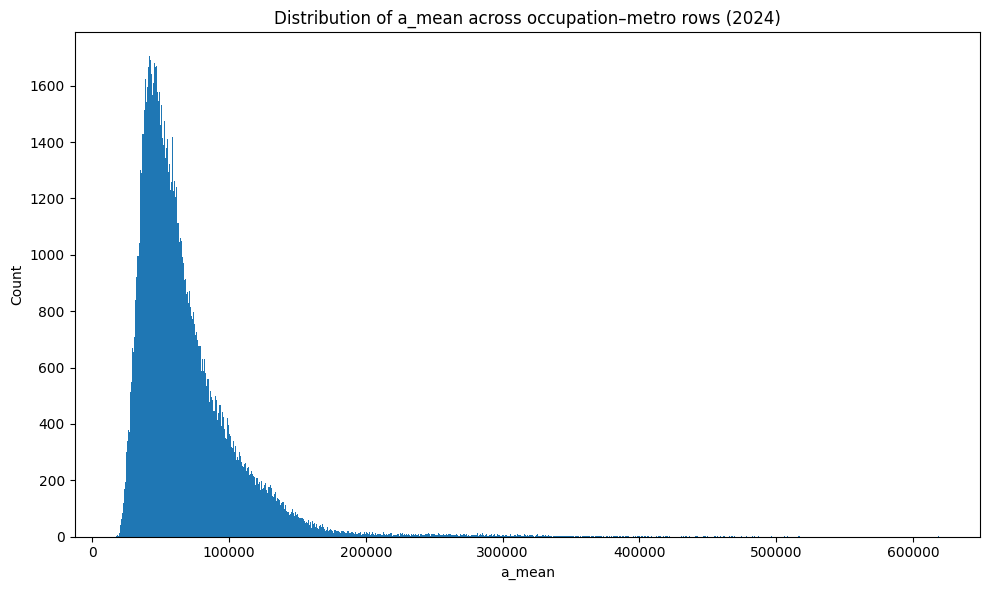

In [15]:

plot_df = eda_pd.dropna(subset=[wage_col]).copy()

plt.figure(figsize=(10, 6))
plt.hist(plot_df[wage_col], bins=1000)
plt.title(f"Distribution of {wage_col} across occupation–metro rows (2024)")
plt.xlabel(wage_col)
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_wage_distribution.png", dpi=150)
plt.show()


## 14. Graph 2 — annual rent vs annual wage

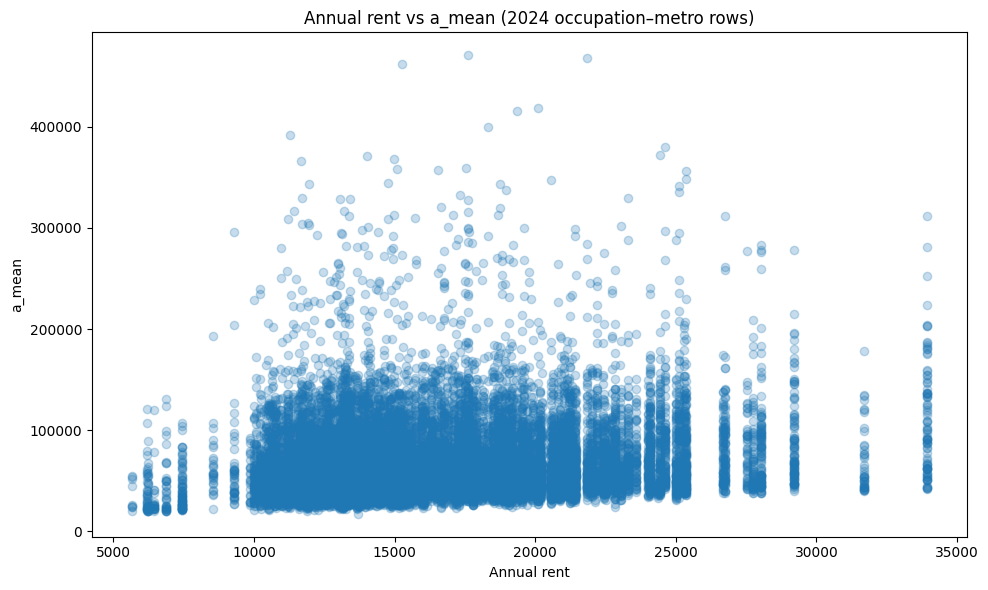

In [16]:

plot_df = eda_pd.dropna(subset=["annual_rent", wage_col]).copy()

# Sample if the dataset is very large, to keep plotting responsive.
if len(plot_df) > 20000:
    plot_df = plot_df.sample(20000, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["annual_rent"], plot_df[wage_col], alpha=0.25)
plt.title(f"Annual rent vs {wage_col} (2024 occupation–metro rows)")
plt.xlabel("Annual rent")
plt.ylabel(wage_col)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rent_vs_wage_scatter.png", dpi=150)
plt.show()


## 15. Pick a sample occupation for metro comparisons

In [17]:

candidate_keywords = [
    "software developers",
    "registered nurses",
    "accountants",
    "data scientists",
    "financial analysts",
]

selected_occ = None
all_occ_titles = merged.select("occ_title").drop_nulls().unique().to_series().to_list()

for keyword in candidate_keywords:
    matches = [title for title in all_occ_titles if keyword in str(title).lower()]
    if matches:
        selected_occ = matches[0]
        break

if selected_occ is None:
    if "tot_emp" in merged.columns:
        selected_occ = (
            merged.group_by("occ_title")
            .agg(pl.sum("tot_emp").alias("total_emp"))
            .sort("total_emp", descending=True)
            .select("occ_title")
            .item()
        )
    else:
        selected_occ = merged.select("occ_title").drop_nulls().head(1).item()

print("Selected occupation for metro-level comparison:")
print(selected_occ)


Selected occupation for metro-level comparison:
Software Developers


## 16. Graph 3 — top metros for a selected occupation by affordability

,bls_msa_name,a_mean,annual_rent,rent_to_annual_mean_wage_ratio,tot_emp,loc_quotient
0,"Johnstown, PA",102040.0,8544,0.083732,110.0,0.22
1,"Hickory-Lenoir-Morganton, NC",130880.0,11208,0.085636,360.0,0.21
2,"Wheeling, WV-OH",108590.0,9300,0.085643,90.0,0.14
3,"Aguadilla, PR",77700.0,6864,0.088340,120.0,0.23
4,"Weirton-Steubenville, WV-OH",112280.0,9996,0.089027,60.0,0.15
5,"Paducah, KY-IL",110900.0,9876,0.089053,140.0,0.25
6,"Texarkana, TX-AR",125650.0,11268,0.089678,90.0,0.14
7,"Ames, IA",124510.0,11400,0.091559,440.0,0.73
8,"Pittsfield, MA",144070.0,13224,0.091789,310.0,0.51
9,"Lima, OH",115070.0,10668,0.092709,150.0,0.27


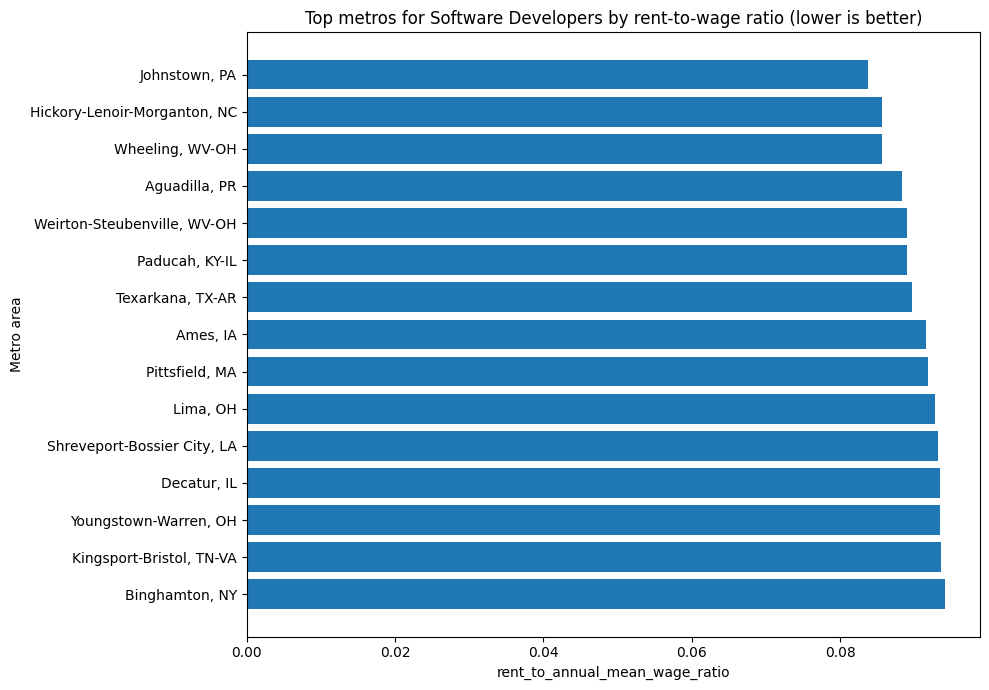

In [18]:

occ_df = (
    merged
    .filter(pl.col("occ_title") == selected_occ)
    .filter(pl.col(ratio_col).is_not_null())
    .sort(ratio_col)
    .head(15)
    .select(["bls_msa_name", wage_col, "annual_rent", ratio_col, *[c for c in ["tot_emp", "loc_quotient"] if c in merged.columns]])
    .to_pandas()
)

display(occ_df)

plt.figure(figsize=(10, 7))
plt.barh(occ_df["bls_msa_name"], occ_df[ratio_col])
plt.title(f"Top metros for {selected_occ} by rent-to-wage ratio (lower is better)")
plt.xlabel(ratio_col)
plt.ylabel("Metro area")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_selected_occupation_affordability.png", dpi=150)
plt.show()


## 17. Graph 4 — location quotient vs annual wage for the selected occupation

,bls_msa_name,loc_quotient,a_mean,tot_emp
0,"Abilene, TX",0.33,105960.0,260.0
1,"Aguadilla, PR",0.23,77700.0,120.0
2,"Akron, OH",0.67,107780.0,2290.0
3,"Albany, GA",0.28,110190.0,180.0
4,"Albany, OR",0.21,127450.0,100.0


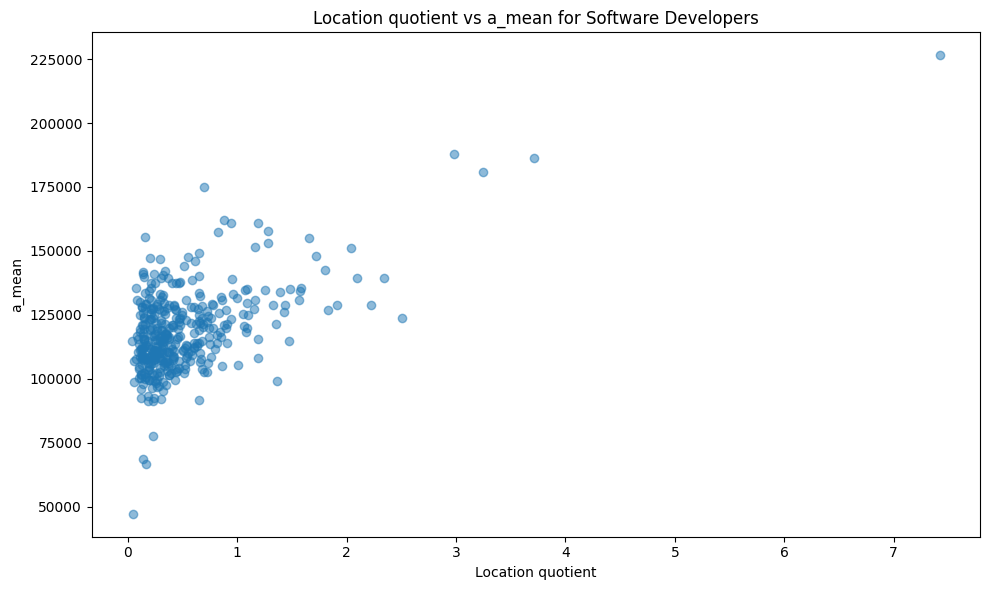

In [19]:

if "loc_quotient" in merged.columns:
    lq_df = (
        merged
        .filter(pl.col("occ_title") == selected_occ)
        .filter(pl.col("loc_quotient").is_not_null() & pl.col(wage_col).is_not_null())
        .select(["bls_msa_name", "loc_quotient", wage_col, *[c for c in ["tot_emp"] if c in merged.columns]])
        .to_pandas()
    )

    display(lq_df.head())

    plt.figure(figsize=(10, 6))
    plt.scatter(lq_df["loc_quotient"], lq_df[wage_col], alpha=0.5)
    plt.title(f"Location quotient vs {wage_col} for {selected_occ}")
    plt.xlabel("Location quotient")
    plt.ylabel(wage_col)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "04_selected_occupation_lq_vs_wage.png", dpi=150)
    plt.show()
else:
    print("The BLS raw file did not expose a location quotient column after cleaning.")


## 18. Graph 5 — distribution of affordability ratios for high-employment occupations

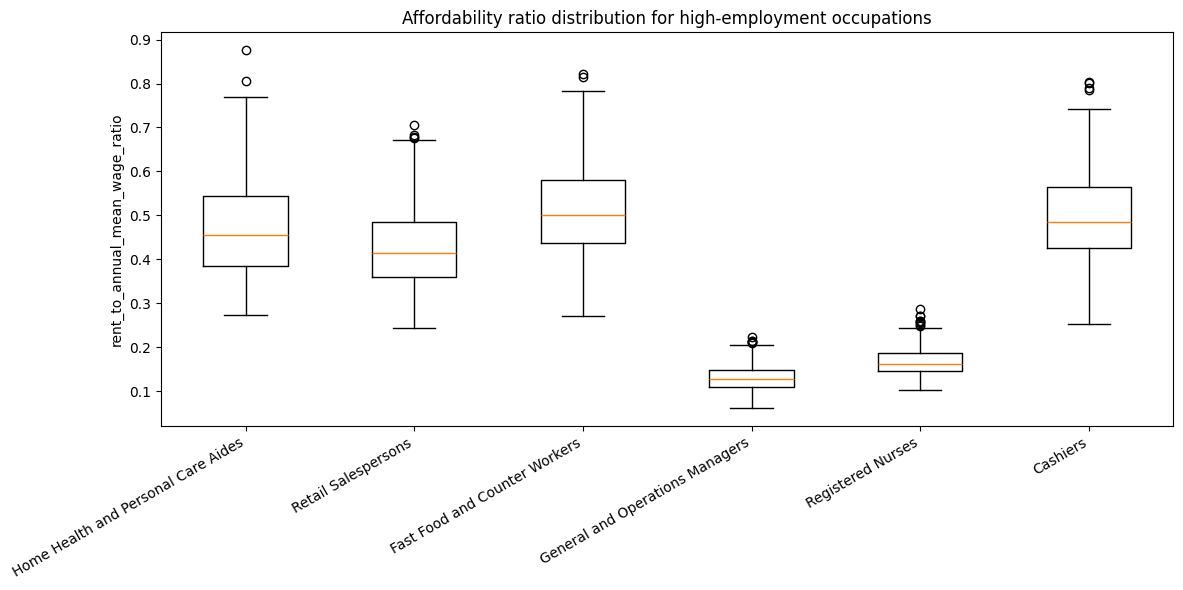

In [20]:

if "tot_emp" in merged.columns:
    top_occ = (
        merged.group_by("occ_title")
        .agg(pl.sum("tot_emp").alias("total_emp"))
        .sort("total_emp", descending=True)
        .head(6)
        .select("occ_title")
        .to_series()
        .to_list()
    )

    box_df = (
        merged
        .filter(pl.col("occ_title").is_in(top_occ))
        .filter(pl.col(ratio_col).is_not_null())
        .select(["occ_title", ratio_col])
        .to_pandas()
    )

    grouped_values = [box_df.loc[box_df["occ_title"] == occ, ratio_col].values for occ in top_occ]

    plt.figure(figsize=(12, 6))
    plt.boxplot(grouped_values, tick_labels=top_occ, vert=True)
    plt.title("Affordability ratio distribution for high-employment occupations")
    plt.ylabel(ratio_col)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "05_affordability_boxplot_top_occupations.png", dpi=150)
    plt.show()
else:
    print("The BLS raw file did not expose a total employment column after cleaning.")


## 19. Final output summary

In [21]:

summary = {
    "raw_bls_csv": str(BLS_RAW_CSV_PATH),
    "raw_acs_csv": str(ACS_RAW_CSV_PATH),
    "clean_bls_csv": str(BLS_CLEAN_CSV_PATH),
    "clean_acs_csv": str(ACS_CLEAN_CSV_PATH),
    "merged_csv": str(MERGED_CSV_PATH),
    "metro_crosswalk_csv": str(BLS_CROSSWALK_CSV_PATH),
    "figures_dir": str(FIG_DIR),
    "unmatched_bls_metros_csv": str(UNMATCHED_BLS_METROS_CSV_PATH),
}

display(pd.DataFrame(summary.items(), columns=["artifact", "path"]))


,artifact,path
0,raw_bls_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
1,raw_acs_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
2,clean_bls_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
3,clean_acs_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
4,merged_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
5,metro_crosswalk_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
6,figures_dir,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
7,unmatched_bls_metros_csv,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...


## 19. Build metro profiles for clustering

In [24]:
# We want to answer: which locations are similar to each other?
# So instead of clustering raw occupation–metro rows directly,
# we build one profile per metro by aggregating across occupation–metro rows.

cluster_wage_col = wage_col
cluster_ratio_col = ratio_col

metro_base = (
    merged
    .with_columns([
        pl.col("occ_code").cast(pl.Utf8).str.slice(0, 2).alias("soc_major"),
        pl.when(pl.col("loc_quotient").is_not_null())
        .then((pl.col("loc_quotient") > 1.25).cast(pl.Float64))
        .otherwise(None)
        .alias("high_lq_flag"),
    ])
    .group_by(["cbsa_code", "bls_msa_name"])
    .agg([
        pl.first("annual_rent").alias("annual_rent"),
        pl.first("median_household_income").alias("median_household_income"),
        pl.first("population").alias("population"),

        # Metro-level summaries across occupation rows
        pl.col(cluster_wage_col).mean().alias("mean_occ_wage"),
        pl.col(cluster_wage_col).median().alias("median_occ_wage"),
        pl.col(cluster_wage_col).std().alias("std_occ_wage"),

        pl.col(cluster_ratio_col).mean().alias("mean_affordability_ratio"),
        pl.col(cluster_ratio_col).median().alias("median_affordability_ratio"),
        pl.col(cluster_ratio_col).std().alias("std_affordability_ratio"),

        pl.col("loc_quotient").mean().alias("mean_loc_quotient"),
        pl.col("high_lq_flag").mean().alias("share_high_lq"),
        pl.col("jobs_1000").mean().alias("mean_jobs_1000"),
        pl.col("tot_emp").sum().alias("metro_occ_emp_sum"),
        pl.len().alias("n_occ_rows"),
    ])
    .with_columns([
        pl.when(pl.col("population").is_not_null() & (pl.col("population") > 0))
        .then(pl.col("population").log())
        .otherwise(None)
        .alias("log_population"),

        pl.when(pl.col("metro_occ_emp_sum").is_not_null() & (pl.col("metro_occ_emp_sum") > 0))
        .then(pl.col("metro_occ_emp_sum").log())
        .otherwise(None)
        .alias("log_metro_occ_emp_sum"),
    ])
)

print_shape("Metro base profile table", metro_base)
display_pl(metro_base)

Metro base profile table: 393 rows × 18 cols


,cbsa_code,bls_msa_name,annual_rent,median_household_income,population,mean_occ_wage,median_occ_wage,std_occ_wage,mean_affordability_ratio,median_affordability_ratio,std_affordability_ratio,mean_loc_quotient,share_high_lq,mean_jobs_1000,metro_occ_emp_sum,n_occ_rows,log_population,log_metro_occ_emp_sum
0,34740,"Muskegon-Norton Shores, MI",11724,60829,177428,60821.596639,51325.0,31709.405371,0.228968,0.228455,0.083400,1.810378,0.361345,3.675761,54650.0,238,12.086320,10.908704
1,13020,"Bay City, MI",11712,64694,102651,59355.745856,51380.0,30010.263987,0.237563,0.227949,0.092502,1.328833,0.450000,4.677894,28070.0,181,11.539090,10.242457
2,47300,"Visalia, CA",16608,69880,483546,69682.724719,57800.0,33739.051009,0.281028,0.287341,0.099570,1.586601,0.243626,2.701283,162260.0,358,13.088902,11.996955
3,23540,"Gainesville, FL",16524,61949,360881,62085.661972,53960.0,30423.063347,0.312214,0.306227,0.110769,1.252648,0.233803,2.553070,137280.0,359,12.796304,11.829778
4,30980,"Longview, TX",13092,65711,295490,59294.489796,48820.0,33220.974619,0.271885,0.268169,0.110420,1.491036,0.322485,2.764710,109910.0,344,12.596390,11.607417
5,31540,"Madison, WI",17244,89714,707606,74661.596330,65250.0,39698.541172,0.279429,0.264276,0.112293,1.330933,0.330224,1.832677,398230.0,553,13.469643,12.894785
6,39460,"Punta Gorda, FL",22116,72868,212122,62440.046512,52970.0,34865.000854,0.424125,0.417519,0.153630,1.387042,0.450704,4.116408,49110.0,216,12.264917,10.801818
7,30300,"Lewiston, ID-WA",14052,77382,65370,61076.601307,53010.0,27438.923447,0.267225,0.265082,0.092766,1.317255,0.326797,5.200425,22190.0,153,11.087819,10.007397


## 21. Add broad occupation-mix features

In [27]:
# To make "similar metros" more meaningful, we also add a simple occupational mix profile.
# We use the first two digits of the SOC code ("soc_major") as a broad major-group indicator,
# then compute employment shares for the largest broad groups nationally.

major_emp = (
    merged
    .with_columns(
        pl.col("occ_code").cast(pl.Utf8).str.slice(0, 2).alias("soc_major")
    )
    .filter(pl.col("tot_emp").is_not_null() & (pl.col("tot_emp") > 0))
    .group_by(["cbsa_code", "bls_msa_name", "soc_major"])
    .agg(pl.sum("tot_emp").alias("soc_major_emp"))
)

metro_emp_totals = (
    major_emp
    .group_by(["cbsa_code", "bls_msa_name"])
    .agg(pl.sum("soc_major_emp").alias("metro_occ_emp_sum"))
)

top_soc_majors = (
    major_emp
    .group_by("soc_major")
    .agg(pl.sum("soc_major_emp").alias("national_emp"))
    .sort("national_emp", descending=True)
    .head(8)
    .select("soc_major")
    .to_series()
    .to_list()
)

major_mix_wide = (
    major_emp
    .filter(pl.col("soc_major").is_in(top_soc_majors))
    .join(
        metro_emp_totals,
        on=["cbsa_code", "bls_msa_name"],
        how="left",
    )
    .with_columns(
        (pl.col("soc_major_emp") / pl.col("metro_occ_emp_sum")).alias("emp_share")
    )
    .with_columns(
        (pl.lit("emp_share_soc_") + pl.col("soc_major")).alias("feature_name")
    )
    .select(["cbsa_code", "bls_msa_name", "feature_name", "emp_share"])
    .pivot(
        index=["cbsa_code", "bls_msa_name"],
        on="feature_name",
        values="emp_share",
        aggregate_function="first",
    )
)

metro_cluster_df = metro_base.join(
    major_mix_wide,
    on=["cbsa_code", "bls_msa_name"],
    how="left",
)

share_cols = [c for c in metro_cluster_df.columns if c.startswith("emp_share_soc_")]
if share_cols:
    metro_cluster_df = metro_cluster_df.with_columns(
        [pl.col(c).fill_null(0.0).alias(c) for c in share_cols]
    )

print_shape("Metro clustering feature table", metro_cluster_df)
display_pl(metro_cluster_df)
print("Top SOC major groups used in the occupational mix features:", top_soc_majors)

Metro clustering feature table: 393 rows × 26 cols


,cbsa_code,bls_msa_name,annual_rent,median_household_income,population,mean_occ_wage,median_occ_wage,std_occ_wage,mean_affordability_ratio,median_affordability_ratio,...,log_population,log_metro_occ_emp_sum,emp_share_soc_35,emp_share_soc_41,emp_share_soc_29,emp_share_soc_25,emp_share_soc_11,emp_share_soc_43,emp_share_soc_53,emp_share_soc_13
0,34740,"Muskegon-Norton Shores, MI",11724,60829,177428,60821.596639,51325.0,31709.405371,0.228968,0.228455,...,12.086320,10.908704,0.124794,0.113998,0.060201,0.049588,0.054346,0.098262,0.092040,0.036597
1,13020,"Bay City, MI",11712,64694,102651,59355.745856,51380.0,30010.263987,0.237563,0.227949,...,11.539090,10.242457,0.130388,0.109369,0.059850,0.034913,0.055575,0.120770,0.098682,0.039544
2,47300,"Visalia, CA",16608,69880,483546,69682.724719,57800.0,33739.051009,0.281028,0.287341,...,13.088902,11.996955,0.081597,0.076852,0.046715,0.079810,0.043202,0.092136,0.111734,0.034204
3,23540,"Gainesville, FL",16524,61949,360881,62085.661972,53960.0,30423.063347,0.312214,0.306227,...,12.796304,11.829778,0.104895,0.087850,0.111160,0.047421,0.065924,0.150204,0.068473,0.058421
4,30980,"Longview, TX",13092,65711,295490,59294.489796,48820.0,33220.974619,0.271885,0.268169,...,12.596390,11.607417,0.092712,0.098899,0.057684,0.065235,0.072423,0.122919,0.097807,0.039123
5,31540,"Madison, WI",17244,89714,707606,74661.596330,65250.0,39698.541172,0.279429,0.264276,...,13.469643,12.894785,0.082415,0.083771,0.070864,0.063581,0.059790,0.119303,0.071542,0.082164
6,39460,"Punta Gorda, FL",22116,72868,212122,62440.046512,52970.0,34865.000854,0.424125,0.417519,...,12.264917,10.801818,0.150682,0.130116,0.077581,0.016290,0.057015,0.134596,0.090002,0.043372
7,30300,"Lewiston, ID-WA",14052,77382,65370,61076.601307,53010.0,27438.923447,0.267225,0.265082,...,11.087819,10.007397,0.107706,0.095989,0.064894,0.047769,0.059036,0.154574,0.099144,0.041009


Top SOC major groups used in the occupational mix features: ['43', '35', '53', '41', '11', '13', '29', '25']


## 22. Standardize features, choose k, and fit metro clusters

In [28]:
# Build the feature list for clustering.
# Note:
# - We include affordability and wage structure.
# - We include broad occupation mix shares.
# - We include log population, but if you want similarity to be less size-driven,
#   remove "log_population" from the list below.

cluster_feature_cols = [
    "annual_rent",
    "median_household_income",
    "log_population",
    "mean_occ_wage",
    "median_occ_wage",
    "std_occ_wage",
    "mean_affordability_ratio",
    "median_affordability_ratio",
    "std_affordability_ratio",
    "mean_loc_quotient",
    "share_high_lq",
    "mean_jobs_1000",
] + share_cols

cluster_feature_cols = [c for c in cluster_feature_cols if c in metro_cluster_df.columns]

meta_cols = ["cbsa_code", "bls_msa_name", "annual_rent", "median_household_income", "population"]
keep_cols = list(dict.fromkeys(meta_cols + cluster_feature_cols))

metro_cluster_pd = metro_cluster_df.select(keep_cols).to_pandas()

X = metro_cluster_pd[cluster_feature_cols].copy()

# Impute missing values with medians so metros with a few missing features are still usable.
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Standardize because these features are on very different scales.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Choose k using silhouette score over a small candidate range.
candidate_ks = list(range(3, 9))
model_selection_rows = []

for k in candidate_ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    model_selection_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil,
    })

model_selection_pd = pd.DataFrame(model_selection_rows).sort_values("k")
display(model_selection_pd)

best_k = int(
    model_selection_pd
    .sort_values(["silhouette", "inertia"], ascending=[False, True])
    .iloc[0]["k"]
)

print(f"Selected number of clusters (k): {best_k}")

kmeans = KMeans(n_clusters=best_k, n_init=50, random_state=42)
metro_cluster_pd["metro_cluster"] = kmeans.fit_predict(X_scaled) + 1

cluster_summary_pd = (
    metro_cluster_pd
    .groupby("metro_cluster")
    .agg(
        n_metros=("cbsa_code", "count"),
        median_annual_rent=("annual_rent", "median"),
        median_household_income=("median_household_income", "median"),
        avg_mean_occ_wage=("mean_occ_wage", "mean"),
        avg_affordability_ratio=("mean_affordability_ratio", "mean"),
        avg_high_lq_share=("share_high_lq", "mean"),
    )
    .reset_index()
    .sort_values("metro_cluster")
)

display(cluster_summary_pd.round(4))
display(metro_cluster_pd.head())

metro_cluster_pd.to_csv(PROCESSED_DIR / "metro_clusters_2024.csv", index=False)
cluster_summary_pd.to_csv(PROCESSED_DIR / "metro_cluster_summary_2024.csv", index=False)

print(f"Saved metro clusters to:        {PROCESSED_DIR / 'metro_clusters_2024.csv'}")
print(f"Saved cluster summary table to: {PROCESSED_DIR / 'metro_cluster_summary_2024.csv'}")

,k,inertia,silhouette
0,3,5424.553693,0.146422
1,4,4984.722217,0.146748
2,5,4657.451473,0.146058
3,6,4422.241477,0.139427
4,7,4193.529550,0.119562
5,8,4038.126841,0.117907


Selected number of clusters (k): 4


,metro_cluster,n_metros,median_annual_rent,median_household_income,avg_mean_occ_wage,avg_affordability_ratio,avg_high_lq_share
0,1,64,20706.0,95716.5,77421.8794,0.3361,0.2875
1,2,111,12012.0,65256.0,59138.5182,0.2464,0.3818
2,3,52,19002.0,82019.5,66506.5340,0.3545,0.3586
3,4,166,13470.0,72001.0,66595.2136,0.2524,0.3039


,cbsa_code,bls_msa_name,annual_rent,median_household_income,population,log_population,mean_occ_wage,median_occ_wage,std_occ_wage,mean_affordability_ratio,...,mean_jobs_1000,emp_share_soc_35,emp_share_soc_41,emp_share_soc_29,emp_share_soc_25,emp_share_soc_11,emp_share_soc_43,emp_share_soc_53,emp_share_soc_13,metro_cluster
0,34740,"Muskegon-Norton Shores, MI",11724,60829,177428,12.086320,60821.596639,51325.0,31709.405371,0.228968,...,3.675761,0.124794,0.113998,0.060201,0.049588,0.054346,0.098262,0.092040,0.036597,2
1,13020,"Bay City, MI",11712,64694,102651,11.539090,59355.745856,51380.0,30010.263987,0.237563,...,4.677894,0.130388,0.109369,0.059850,0.034913,0.055575,0.120770,0.098682,0.039544,2
2,47300,"Visalia, CA",16608,69880,483546,13.088902,69682.724719,57800.0,33739.051009,0.281028,...,2.701283,0.081597,0.076852,0.046715,0.079810,0.043202,0.092136,0.111734,0.034204,4
3,23540,"Gainesville, FL",16524,61949,360881,12.796304,62085.661972,53960.0,30423.063347,0.312214,...,2.553070,0.104895,0.087850,0.111160,0.047421,0.065924,0.150204,0.068473,0.058421,4
4,30980,"Longview, TX",13092,65711,295490,12.596390,59294.489796,48820.0,33220.974619,0.271885,...,2.764710,0.092712,0.098899,0.057684,0.065235,0.072423,0.122919,0.097807,0.039123,4


Saved metro clusters to:        /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/metro_clusters_2024.csv
Saved cluster summary table to: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/metro_cluster_summary_2024.csv


## 23. Visualize the metro clusters with PCA

,component,explained_variance_ratio
0,PC1,0.376497
1,PC2,0.157524


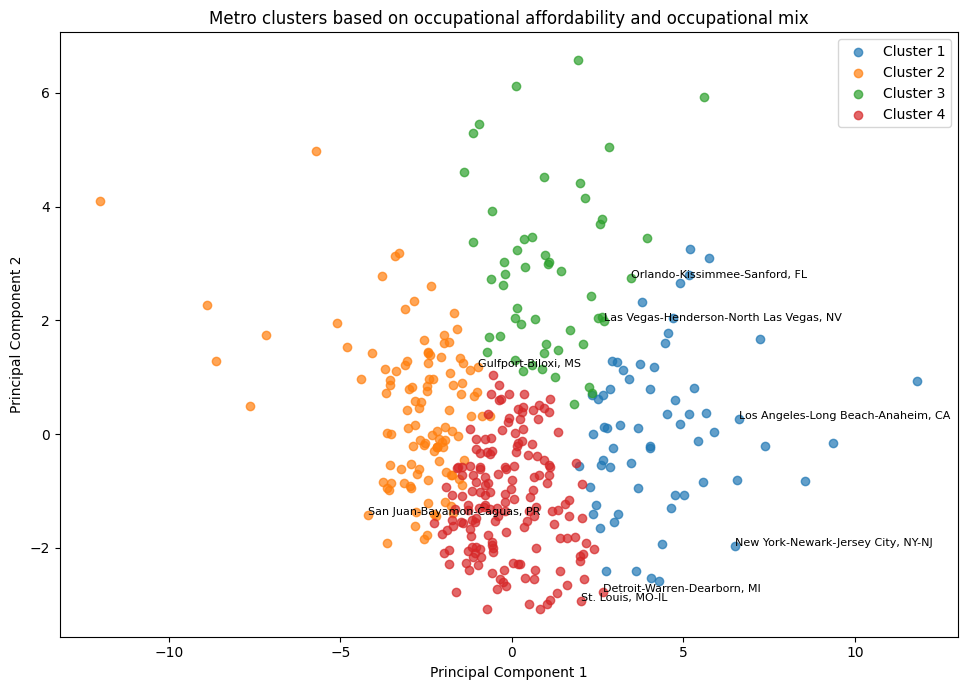

Saved figure: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/figures/06_metro_cluster_pca.png


In [29]:
# PCA gives a 2D projection of the high-dimensional metro feature space.
# This is useful for plotting and for seeing whether clusters are visually distinct.

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

metro_cluster_pd["pc1"] = pcs[:, 0]
metro_cluster_pd["pc2"] = pcs[:, 1]

explained_var_pd = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
display(explained_var_pd)

plt.figure(figsize=(10, 7))

for cluster_id in sorted(metro_cluster_pd["metro_cluster"].unique()):
    subset = metro_cluster_pd[metro_cluster_pd["metro_cluster"] == cluster_id]
    plt.scatter(subset["pc1"], subset["pc2"], alpha=0.7, label=f"Cluster {cluster_id}")

# Label a couple of large metros per cluster so the plot is interpretable.
label_points = (
    metro_cluster_pd
    .sort_values("population", ascending=False)
    .groupby("metro_cluster")
    .head(2)
)

for _, row in label_points.iterrows():
    plt.text(row["pc1"], row["pc2"], row["bls_msa_name"], fontsize=8)

plt.title("Metro clusters based on occupational affordability and occupational mix")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "06_metro_cluster_pca.png", dpi=150)
plt.show()

print(f"Saved figure: {FIG_DIR / '06_metro_cluster_pca.png'}")

## 24. Find metros that are most similar to a chosen metro

In [30]:
# Cluster labels are useful, but for "what metros are most similar to X?"
# pairwise distance is even more useful.
# We compute Euclidean distance in the same standardized feature space used for clustering.

distance_matrix = euclidean_distances(X_scaled, X_scaled)

def most_similar_metros(
    target_metro: str,
    metro_df: pd.DataFrame,
    distance_matrix,
    n_neighbors: int = 10,
) -> pd.DataFrame:
    mask = metro_df["bls_msa_name"] == target_metro

    if not mask.any():
        raise ValueError(
            f"Metro '{target_metro}' not found in metro_cluster_pd."
        )

    target_idx = metro_df.index[mask][0]
    ordered_idx = distance_matrix[target_idx].argsort()
    neighbor_idx = [i for i in ordered_idx if i != target_idx][:n_neighbors]

    result_cols = [
        "cbsa_code",
        "bls_msa_name",
        "metro_cluster",
        "annual_rent",
        "median_household_income",
        "mean_occ_wage",
        "mean_affordability_ratio",
        "share_high_lq",
    ]
    result_cols = [c for c in result_cols if c in metro_df.columns]

    result = metro_df.iloc[neighbor_idx][result_cols].copy()
    result.insert(0, "distance", distance_matrix[target_idx][neighbor_idx])

    return result.sort_values("distance").reset_index(drop=True)

target_metro = (
    "Abilene, TX"
    if "Abilene, TX" in metro_cluster_pd["bls_msa_name"].values
    else metro_cluster_pd.sort_values("population", ascending=False).iloc[0]["bls_msa_name"]
)

print(f"Most similar metros to: {target_metro}")
similar_metros_pd = most_similar_metros(
    target_metro=target_metro,
    metro_df=metro_cluster_pd,
    distance_matrix=distance_matrix,
    n_neighbors=10,
)

display(similar_metros_pd.round(4))

similar_metros_pd.to_csv(PROCESSED_DIR / "similar_metros_example.csv", index=False)
print(f"Saved example similar-metros table to: {PROCESSED_DIR / 'similar_metros_example.csv'}")

Most similar metros to: Abilene, TX


,distance,cbsa_code,bls_msa_name,metro_cluster,annual_rent,median_household_income,mean_occ_wage,mean_affordability_ratio,share_high_lq
0,1.4615,41660,"San Angelo, TX",2,14388,69726,57444.3805,0.3011,0.3392
1,1.9229,31180,"Lubbock, TX",4,14484,64469,60190.9463,0.2941,0.2795
2,1.9939,48660,"Wichita Falls, TX",2,12780,66981,58198.3951,0.2695,0.3374
3,2.4313,41540,"Salisbury, MD",4,16656,70389,66942.3237,0.2999,0.3983
4,2.4650,11100,"Amarillo, TX",4,13164,69595,60343.7092,0.2664,0.2768
5,2.4701,47020,"Victoria, TX",2,13416,65829,58583.5417,0.2790,0.4021
6,2.4835,17300,"Clarksville, TN-KY",4,15120,72347,60732.7243,0.3011,0.3366
7,2.7025,43340,"Shreveport-Bossier City, LA",2,11880,57514,58335.1462,0.2499,0.3884
8,2.7091,30980,"Longview, TX",4,13092,65711,59294.4898,0.2719,0.3225
9,2.7582,47380,"Waco, TX",4,14856,67792,62446.5805,0.2904,0.2621


Saved example similar-metros table to: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/similar_metros_example.csv


## 25. Quick cluster diagnostics by metro

In [31]:
print("Example metros in each cluster:")

example_cluster_metros = (
    metro_cluster_pd
    .sort_values(["metro_cluster", "population"], ascending=[True, False])
    .groupby("metro_cluster")
    .head(8)
    [["metro_cluster", "bls_msa_name", "annual_rent", "median_household_income", "mean_occ_wage", "mean_affordability_ratio"]]
)

display(example_cluster_metros.round(3))

Example metros in each cluster:


,metro_cluster,bls_msa_name,annual_rent,median_household_income,mean_occ_wage,mean_affordability_ratio
387,1,"New York-Newark-Jersey City, NY-NJ",22212,99852,90514.469,0.306
100,1,"Los Angeles-Long Beach-Anaheim, CA",25368,96405,85894.685,0.366
103,1,"Chicago-Naperville-Elgin, IL-IN",17628,90770,78494.698,0.274
12,1,"Dallas-Fort Worth-Arlington, TX",20616,92733,74081.113,0.354
235,1,"Houston-Pasadena-The Woodlands, TX",17628,81417,72489.242,0.308
63,1,"Miami-Fort Lauderdale-West Palm Beach, FL",24996,80625,71629.415,0.431
13,1,"Washington-Arlington-Alexandria, DC-VA-MD-WV",24444,126244,86640.701,0.351
78,1,"Atlanta-Sandy Springs-Roswell, GA",21240,92344,73292.332,0.363
152,2,"San Juan-Bayamon-Caguas, PR",7440,30640,44893.107,0.203
166,2,"Gulfport-Biloxi, MS",13752,65256,60478.740,0.284


## 26. Build occupation profiles for clustering

In [32]:
# We now switch the unit of clustering from metros to occupations.
# One row = one occupation profile, summarized across all metros where it appears.

occ_cluster_wage_col = wage_col
occ_cluster_ratio_col = ratio_col

n_total_metros = merged.select(pl.col("cbsa_code").n_unique()).item()

occupation_profile = (
    merged
    .with_columns([
        pl.col("occ_code").cast(pl.Utf8).str.slice(0, 2).alias("soc_major"),
        pl.when(pl.col("loc_quotient").is_not_null())
        .then((pl.col("loc_quotient") > 1.25).cast(pl.Float64))
        .otherwise(None)
        .alias("high_lq_flag"),
    ])
    .group_by(["occ_code", "occ_title", "soc_major"])
    .agg([
        pl.len().alias("n_metro_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros_present"),

        # Wage structure across metros
        pl.col(occ_cluster_wage_col).mean().alias("mean_wage_across_metros"),
        pl.col(occ_cluster_wage_col).median().alias("median_wage_across_metros"),
        pl.col(occ_cluster_wage_col).std().alias("std_wage_across_metros"),

        # Affordability structure across metros
        pl.col(occ_cluster_ratio_col).mean().alias("mean_affordability_across_metros"),
        pl.col(occ_cluster_ratio_col).median().alias("median_affordability_across_metros"),
        pl.col(occ_cluster_ratio_col).std().alias("std_affordability_across_metros"),

        # Labor-market structure
        pl.col("loc_quotient").mean().alias("mean_loc_quotient"),
        pl.col("high_lq_flag").mean().alias("share_high_lq_metros"),
        pl.col("jobs_1000").mean().alias("mean_jobs_1000"),

        # Employment footprint
        pl.col("tot_emp").sum().alias("total_emp_across_metros"),
        pl.col("tot_emp").mean().alias("mean_emp_across_metros"),
        pl.col("tot_emp").median().alias("median_emp_across_metros"),

        # Metro context experienced by this occupation
        pl.col("annual_rent").mean().alias("mean_metro_annual_rent"),
        pl.col("median_household_income").mean().alias("mean_metro_household_income"),
        pl.col("population").mean().alias("mean_metro_population"),
    ])
    .with_columns([
        (pl.col("n_metros_present") / pl.lit(n_total_metros)).alias("metro_coverage_share"),

        pl.when(pl.col("total_emp_across_metros").is_not_null() & (pl.col("total_emp_across_metros") > 0))
        .then(pl.col("total_emp_across_metros").log())
        .otherwise(None)
        .alias("log_total_emp_across_metros"),

        pl.when(pl.col("mean_metro_population").is_not_null() & (pl.col("mean_metro_population") > 0))
        .then(pl.col("mean_metro_population").log())
        .otherwise(None)
        .alias("log_mean_metro_population"),
    ])
    .sort("occ_code")
)

print_shape("Occupation profile table", occupation_profile)
display_pl(occupation_profile)

Occupation profile table: 823 rows × 23 cols


,occ_code,occ_title,soc_major,n_metro_rows,n_metros_present,mean_wage_across_metros,median_wage_across_metros,std_wage_across_metros,mean_affordability_across_metros,median_affordability_across_metros,...,mean_jobs_1000,total_emp_across_metros,mean_emp_across_metros,median_emp_across_metros,mean_metro_annual_rent,mean_metro_household_income,mean_metro_population,metro_coverage_share,log_total_emp_across_metros,log_mean_metro_population
0,11-1011,Chief Executives,11,333,333,243634.685535,235075.0,64616.524845,0.066003,0.061908,...,1.247006,147360.0,450.642202,120.0,15485.765766,76504.960961,7.962725e+05,0.847328,11.900634,13.587697
1,11-1021,General and Operations Managers,11,393,393,117685.943878,116450.0,19227.179149,0.130510,0.126725,...,20.832741,3005350.0,7706.025641,2125.0,15375.267176,75626.351145,7.554379e+05,1.000000,14.915905,13.535053
2,11-1031,Legislators,11,128,128,68937.019231,64605.0,32929.824911,0.299152,0.264003,...,0.355827,13620.0,107.244094,60.0,17092.312500,81663.812500,1.642867e+06,0.325700,9.519295,14.311953
3,11-2011,Advertising and Promotions Managers,11,70,70,127160.909091,122610.0,27931.476632,0.150627,0.143894,...,0.142951,12370.0,202.786885,80.0,18868.285714,89206.885714,2.794621e+06,0.178117,9.423029,14.843207
4,11-2021,Marketing Managers,11,337,337,142942.275449,139985.0,22577.183323,0.111554,0.109348,...,1.503501,333130.0,994.417910,150.0,15909.721068,77524.982196,8.593214e+05,0.857506,12.716288,13.663898
5,11-2022,Sales Managers,11,389,389,139719.276486,138180.0,20711.453378,0.110950,0.104840,...,2.776490,521950.0,1345.231959,260.0,15427.650386,75880.629820,7.624044e+05,0.989822,13.165327,13.544232
6,11-2032,Public Relations Managers,11,180,180,132897.528090,129215.0,25637.267686,0.131667,0.127782,...,0.452023,64710.0,365.593220,90.0,17349.533333,82555.377778,1.427040e+06,0.458015,11.077671,14.171113
7,11-2033,Fundraising Managers,11,132,132,124981.384615,122645.0,22116.800298,0.144165,0.142299,...,0.313649,30590.0,233.511450,80.0,17897.272727,85594.037879,1.763357e+06,0.335878,10.328428,14.382730


## 27. Standardize features, choose k, and cluster occupations

In [33]:
# Build the numerical feature set for occupation clustering.
# We do NOT include occ_code or occ_title themselves, and we do NOT
# include SOC major as a dummy yet. This lets the clusters emerge from
# wage/affordability/geographic behavior rather than official labels.

occupation_feature_cols = [
    "n_metros_present",
    "metro_coverage_share",
    "mean_wage_across_metros",
    "median_wage_across_metros",
    "std_wage_across_metros",
    "mean_affordability_across_metros",
    "median_affordability_across_metros",
    "std_affordability_across_metros",
    "mean_loc_quotient",
    "share_high_lq_metros",
    "mean_jobs_1000",
    "total_emp_across_metros",
    "mean_emp_across_metros",
    "median_emp_across_metros",
    "log_total_emp_across_metros",
    "mean_metro_annual_rent",
    "mean_metro_household_income",
    "log_mean_metro_population",
]

occupation_feature_cols = [c for c in occupation_feature_cols if c in occupation_profile.columns]

occupation_cluster_pd = occupation_profile.select(
    ["occ_code", "occ_title", "soc_major"] + occupation_feature_cols
).to_pandas()

X_occ = occupation_cluster_pd[occupation_feature_cols].copy()

occ_imputer = SimpleImputer(strategy="median")
X_occ_imputed = occ_imputer.fit_transform(X_occ)

occ_scaler = StandardScaler()
X_occ_scaled = occ_scaler.fit_transform(X_occ_imputed)

occ_candidate_ks = list(range(4, 11))
occ_model_selection_rows = []

for k in occ_candidate_ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_occ_scaled)
    sil = silhouette_score(X_occ_scaled, labels)

    occ_model_selection_rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": sil,
    })

occ_model_selection_pd = pd.DataFrame(occ_model_selection_rows).sort_values("k")
display(occ_model_selection_pd)

best_occ_k = int(
    occ_model_selection_pd
    .sort_values(["silhouette", "inertia"], ascending=[False, True])
    .iloc[0]["k"]
)

print(f"Selected number of occupation clusters (k): {best_occ_k}")

occ_kmeans = KMeans(n_clusters=best_occ_k, n_init=50, random_state=42)
occupation_cluster_pd["occupation_cluster"] = occ_kmeans.fit_predict(X_occ_scaled) + 1

occupation_cluster_summary_pd = (
    occupation_cluster_pd
    .groupby("occupation_cluster")
    .agg(
        n_occupations=("occ_code", "count"),
        avg_mean_wage=("mean_wage_across_metros", "mean"),
        avg_mean_affordability=("mean_affordability_across_metros", "mean"),
        avg_metro_coverage=("metro_coverage_share", "mean"),
        avg_mean_loc_quotient=("mean_loc_quotient", "mean"),
        avg_total_emp=("total_emp_across_metros", "mean"),
    )
    .reset_index()
    .sort_values("occupation_cluster")
)

display(occupation_cluster_summary_pd.round(4))
display(occupation_cluster_pd.head())

occupation_cluster_pd.to_csv(PROCESSED_DIR / "occupation_clusters_2024.csv", index=False)
occupation_cluster_summary_pd.to_csv(PROCESSED_DIR / "occupation_cluster_summary_2024.csv", index=False)

print(f"Saved occupation clusters to:        {PROCESSED_DIR / 'occupation_clusters_2024.csv'}")
print(f"Saved occupation cluster summary to: {PROCESSED_DIR / 'occupation_cluster_summary_2024.csv'}")

,k,inertia,silhouette
0,4,7319.721633,0.297758
1,5,6304.109581,0.281610
2,6,5595.442663,0.257648
3,7,4904.858458,0.256325
4,8,4404.171888,0.254659
5,9,3969.027615,0.261008
6,10,3664.758353,0.246941


Selected number of occupation clusters (k): 4


,occupation_cluster,n_occupations,avg_mean_wage,avg_mean_affordability,avg_metro_coverage,avg_mean_loc_quotient,avg_total_emp
0,1,330,54820.9517,0.3565,0.1812,3.4030,1.574227e+04
1,2,143,139023.4636,0.1610,0.1949,2.3979,2.039287e+04
2,3,23,48994.6679,0.3584,0.9552,1.0983,1.971135e+06
3,4,327,66758.5953,0.2721,0.7632,2.1955,2.322581e+05


,occ_code,occ_title,soc_major,n_metros_present,metro_coverage_share,mean_wage_across_metros,median_wage_across_metros,std_wage_across_metros,mean_affordability_across_metros,median_affordability_across_metros,...,share_high_lq_metros,mean_jobs_1000,total_emp_across_metros,mean_emp_across_metros,median_emp_across_metros,log_total_emp_across_metros,mean_metro_annual_rent,mean_metro_household_income,log_mean_metro_population,occupation_cluster
0,11-1011,Chief Executives,11,333,0.847328,243634.685535,235075.0,64616.524845,0.066003,0.061908,...,0.201835,1.247006,147360.0,450.642202,120.0,11.900634,15485.765766,76504.960961,13.587697,2
1,11-1021,General and Operations Managers,11,393,1.000000,117685.943878,116450.0,19227.179149,0.130510,0.126725,...,0.105128,20.832741,3005350.0,7706.025641,2125.0,14.915905,15375.267176,75626.351145,13.535053,3
2,11-1031,Legislators,11,128,0.325700,68937.019231,64605.0,32929.824911,0.299152,0.264003,...,0.503937,0.355827,13620.0,107.244094,60.0,9.519295,17092.312500,81663.812500,14.311953,1
3,11-2011,Advertising and Promotions Managers,11,70,0.178117,127160.909091,122610.0,27931.476632,0.150627,0.143894,...,0.278689,0.142951,12370.0,202.786885,80.0,9.423029,18868.285714,89206.885714,14.843207,2
4,11-2021,Marketing Managers,11,337,0.857506,142942.275449,139985.0,22577.183323,0.111554,0.109348,...,0.068657,1.503501,333130.0,994.417910,150.0,12.716288,15909.721068,77524.982196,13.663898,4


Saved occupation clusters to:        /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/occupation_clusters_2024.csv
Saved occupation cluster summary to: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/occupation_cluster_summary_2024.csv


## 28. Visualize occupation clusters with PCA

,component,explained_variance_ratio
0,PC1,0.400001
1,PC2,0.262506


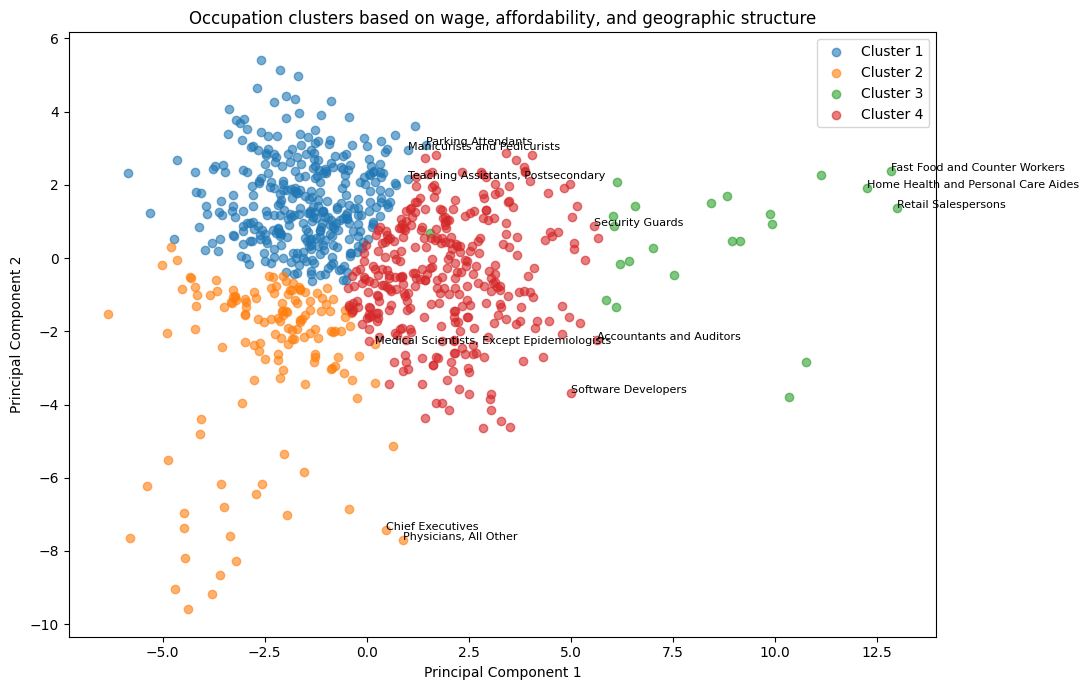

Saved figure: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/figures/07_occupation_cluster_pca.png


In [34]:
occ_pca = PCA(n_components=2, random_state=42)
occ_pcs = occ_pca.fit_transform(X_occ_scaled)

occupation_cluster_pd["pc1"] = occ_pcs[:, 0]
occupation_cluster_pd["pc2"] = occ_pcs[:, 1]

occ_explained_var_pd = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": occ_pca.explained_variance_ratio_,
})
display(occ_explained_var_pd)

plt.figure(figsize=(11, 7))

for cluster_id in sorted(occupation_cluster_pd["occupation_cluster"].unique()):
    subset = occupation_cluster_pd[occupation_cluster_pd["occupation_cluster"] == cluster_id]
    plt.scatter(subset["pc1"], subset["pc2"], alpha=0.6, label=f"Cluster {cluster_id}")

# Label a few occupations with large total employment so the plot is interpretable.
label_occ = (
    occupation_cluster_pd
    .sort_values("total_emp_across_metros", ascending=False)
    .groupby("occupation_cluster")
    .head(3)
)

for _, row in label_occ.iterrows():
    plt.text(row["pc1"], row["pc2"], row["occ_title"], fontsize=8)

plt.title("Occupation clusters based on wage, affordability, and geographic structure")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_occupation_cluster_pca.png", dpi=150)
plt.show()

print(f"Saved figure: {FIG_DIR / '07_occupation_cluster_pca.png'}")

## 29. Find occupations most similar to a chosen occupation

In [35]:
occ_distance_matrix = euclidean_distances(X_occ_scaled, X_occ_scaled)

def most_similar_occupations(
    target_occupation: str,
    occ_df: pd.DataFrame,
    distance_matrix,
    n_neighbors: int = 10,
) -> pd.DataFrame:
    mask = occ_df["occ_title"] == target_occupation

    if not mask.any():
        raise ValueError(
            f"Occupation '{target_occupation}' not found in occupation_cluster_pd."
        )

    target_idx = occ_df.index[mask][0]
    ordered_idx = distance_matrix[target_idx].argsort()
    neighbor_idx = [i for i in ordered_idx if i != target_idx][:n_neighbors]

    result_cols = [
        "occ_code",
        "occ_title",
        "soc_major",
        "occupation_cluster",
        "mean_wage_across_metros",
        "mean_affordability_across_metros",
        "metro_coverage_share",
        "mean_loc_quotient",
        "total_emp_across_metros",
    ]
    result_cols = [c for c in result_cols if c in occ_df.columns]

    result = occ_df.iloc[neighbor_idx][result_cols].copy()
    result.insert(0, "distance", distance_matrix[target_idx][neighbor_idx])

    return result.sort_values("distance").reset_index(drop=True)

candidate_occ_titles = [
    "Industrial Truck and Tractor Operators",
    "Cleaners of Vehicles and Equipment",
    "Chief Executives",
    "General and Operations Managers",
]

selected_occ_for_similarity = None
for title in candidate_occ_titles:
    if title in occupation_cluster_pd["occ_title"].values:
        selected_occ_for_similarity = title
        break

if selected_occ_for_similarity is None:
    selected_occ_for_similarity = (
        occupation_cluster_pd
        .sort_values("total_emp_across_metros", ascending=False)
        .iloc[0]["occ_title"]
    )

print(f"Most similar occupations to: {selected_occ_for_similarity}")

similar_occupations_pd = most_similar_occupations(
    target_occupation=selected_occ_for_similarity,
    occ_df=occupation_cluster_pd,
    distance_matrix=occ_distance_matrix,
    n_neighbors=10,
)

display(similar_occupations_pd.round(4))

similar_occupations_pd.to_csv(PROCESSED_DIR / "similar_occupations_example.csv", index=False)
print(f"Saved example similar-occupations table to: {PROCESSED_DIR / 'similar_occupations_example.csv'}")

Most similar occupations to: Industrial Truck and Tractor Operators


,distance,occ_code,occ_title,soc_major,occupation_cluster,mean_wage_across_metros,mean_affordability_across_metros,metro_coverage_share,mean_loc_quotient,total_emp_across_metros
0,0.5784,43-5071,"Shipping, Receiving, and Inventory Clerks",43,4,43513.3673,0.3528,0.9975,0.9789,746740.0
1,0.6761,43-6013,Medical Secretaries and Administrative Assistants,43,4,42865.1918,0.3562,0.9949,1.0772,734690.0
2,0.7378,31-9092,Medical Assistants,31,4,42282.6410,0.3625,0.9924,1.1136,708260.0
3,1.0699,53-3033,Light Truck Drivers,53,4,45442.6972,0.3374,1.0000,1.0131,881940.0
4,1.1271,51-9061,"Inspectors, Testers, Sorters, Samplers, and We...",51,4,51310.0260,0.3013,0.9822,1.1397,485090.0
5,1.1758,47-2031,Carpenters,47,4,56790.4627,0.2742,0.9898,1.0084,606720.0
6,1.2079,49-3023,Automotive Service Technicians and Mechanics,49,4,52778.2908,0.2892,0.9975,1.1732,591940.0
7,1.2287,37-3011,Landscaping and Groundskeeping Workers,37,4,38643.6480,0.3960,0.9975,1.0771,820010.0
8,1.2523,29-2052,Pharmacy Technicians,29,4,43439.0840,0.3511,1.0000,1.1169,424990.0
9,1.4575,47-2061,Construction Laborers,47,4,48491.5522,0.3214,1.0000,1.0969,887430.0


Saved example similar-occupations table to: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/similar_occupations_example.csv


## 30. Quick examples of occupations in each cluster

In [36]:
print("Example occupations in each cluster:")

example_cluster_occupations = (
    occupation_cluster_pd
    .sort_values(["occupation_cluster", "total_emp_across_metros"], ascending=[True, False])
    .groupby("occupation_cluster")
    .head(10)
    [[
        "occupation_cluster",
        "occ_title",
        "mean_wage_across_metros",
        "mean_affordability_across_metros",
        "metro_coverage_share",
        "mean_loc_quotient",
        "total_emp_across_metros",
    ]]
)

display(example_cluster_occupations.round(3))

Example occupations in each cluster:


,occupation_cluster,occ_title,mean_wage_across_metros,mean_affordability_across_metros,metro_coverage_share,mean_loc_quotient,total_emp_across_metros
461,1,Manicurists and Pedicurists,36931.304,0.471,0.468,1.078,134770.0
801,1,Parking Attendants,32446.667,0.516,0.534,0.853,124800.0
259,1,"Teaching Assistants, Postsecondary",44539.778,0.390,0.346,2.068,117090.0
521,1,Reservation and Transportation Ticket Agents a...,45068.559,0.410,0.308,1.053,106620.0
449,1,"Ushers, Lobby Attendants, and Ticket Takers",30003.651,0.566,0.481,1.073,102700.0
429,1,"Food Preparation and Serving Related Workers, ...",32840.116,0.526,0.440,1.520,73890.0
409,1,Crossing Guards and Flaggers,41126.848,0.423,0.471,1.223,73770.0
413,1,"Protective Service Workers, All Other",47731.735,0.367,0.499,1.442,68730.0
161,1,Biological Technicians,52966.265,0.331,0.425,1.484,62880.0
770,1,"Paper Goods Machine Setters, Operators, and Te...",49395.738,0.330,0.326,2.370,57120.0
